
# Assignment 5: Bankruptcy Prediction

This notebook follows the assignment workflow end to end: define the problem, inspect the target, build a stratified `70/15/15` split, compare exactly five experiments, select the finalist using validation results only, and evaluate the chosen model on the test set once at the end.



## 1. Problem Definition

- Target variable: `Bankrupt?`
- Positive class: `1`, meaning the company went bankrupt
- Business goal: help a risk team identify companies that may need closer review before they fail
- Class balance: this is strongly imbalanced, so accuracy alone would be misleading
- Primary discrimination metric: `PR-AUC`, because it focuses on how well the model surfaces the rare positive class
- Primary calibration metric: `Brier score`, because it checks whether predicted probabilities are believable enough to support risk decisions
- Thresholded metrics: precision, recall, and `F2-score` will be used only to describe one operating point, not to choose the winning model


In [1]:

from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.calibration import CalibrationDisplay, calibration_curve
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    PrecisionRecallDisplay,
    RocCurveDisplay,
    confusion_matrix,
)
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from xgboost import XGBClassifier

from src.model_utils import (
    RANDOM_STATE,
    compute_metrics,
    evaluate_experiment,
    find_best_threshold,
    make_scale_pos_weight,
    select_top_features,
    split_balance,
)

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", 120)
pd.set_option("display.float_format", lambda value: f"{value:0.4f}")

DATA_PATH = Path("data/data.csv")
TARGET = "Bankrupt?"

df = pd.read_csv(DATA_PATH)
df.head()


,Bankrupt?,ROA(C) before interest and depreciation before interest,ROA(A) before interest and % after tax,ROA(B) before interest and depreciation after tax,Operating Gross Margin,Realized Sales Gross Margin,Operating Profit Rate,Pre-tax net Interest Rate,After-tax net Interest Rate,Non-industry income and expenditure/revenue,Continuous interest rate (after tax),Operating Expense Rate,Research and development expense rate,Cash flow rate,Interest-bearing debt interest rate,Tax rate (A),Net Value Per Share (B),Net Value Per Share (A),Net Value Per Share (C),Persistent EPS in the Last Four Seasons,Cash Flow Per Share,Revenue Per Share (Yuan ¥),Operating Profit Per Share (Yuan ¥),Per Share Net profit before tax (Yuan ¥),Realized Sales Gross Profit Growth Rate,Operating Profit Growth Rate,After-tax Net Profit Growth Rate,Regular Net Profit Growth Rate,Continuous Net Profit Growth Rate,Total Asset Growth Rate,Net Value Growth Rate,Total Asset Return Growth Rate Ratio,Cash Reinvestment %,Current Ratio,Quick Ratio,Interest Expense Ratio,Total debt/Total net worth,Debt ratio %,Net worth/Assets,Long-term fund suitability ratio (A),Borrowing dependency,Contingent liabilities/Net worth,Operating profit/Paid-in capital,Net profit before tax/Paid-in capital,Inventory and accounts receivable/Net value,Total Asset Turnover,Accounts Receivable Turnover,Average Collection Days,Inventory Turnover Rate (times),Fixed Assets Turnover Frequency,Net Worth Turnover Rate (times),Revenue per person,Operating profit per person,Allocation rate per person,Working Capital to Total Assets,Quick Assets/Total Assets,Current Assets/Total Assets,Cash/Total Assets,Quick Assets/Current Liability,Cash/Current Liability,Current Liability to Assets,Operating Funds to Liability,Inventory/Working Capital,Inventory/Current Liability,Current Liabilities/Liability,Working Capital/Equity,Current Liabilities/Equity,Long-term Liability to Current Assets,Retained Earnings to Total Assets,Total income/Total expense,Total expense/Assets,Current Asset Turnover Rate,Quick Asset Turnover Rate,Working capitcal Turnover Rate,Cash Turnover Rate,Cash Flow to Sales,Fixed Assets to Assets,Current Liability to Liability,Current Liability to Equity,Equity to Long-term Liability,Cash Flow to Total Assets,Cash Flow to Liability,CFO to Assets,Cash Flow to Equity,Current Liability to Current Assets,Liability-Assets Flag,Net Income to Total Assets,Total assets to GNP price,No-credit Interval,Gross Profit to Sales,Net Income to Stockholder's Equity,Liability to Equity,Degree of Financial Leverage (DFL),Interest Coverage Ratio (Interest expense to EBIT),Net Income Flag,Equity to Liability
0,1,0.3706,0.4244,0.4057,0.6015,0.6015,0.9990,0.7969,0.8088,0.3026,0.7810,0.0001,0.0000,0.4581,0.0007,0.0000,0.1479,0.1479,0.1479,0.1691,0.3117,0.0176,0.0959,0.1387,0.0221,0.8482,0.6890,0.6890,0.2175,4980000000.0000,0.0003,0.2631,0.3637,0.0023,0.0012,0.6300,0.0213,0.2076,0.7924,0.0050,0.3903,0.0065,0.0959,0.1378,0.3980,0.0870,0.0018,0.0035,0.0002,0.0001,0.0329,0.0342,0.3929,0.0371,0.6728,0.1667,0.1906,0.0041,0.0020,0.0001,0.1473,0.3340,0.2769,0.0010,0.6763,0.7213,0.3391,0.0256,0.9032,0.0020,0.0649,701000000.0000,6550000000.0000,0.5938,458000000.0000,0.6716,0.4242,0.6763,0.3391,0.1265,0.6376,0.4586,0.5204,0.3129,0.1183,0,0.7168,0.0092,0.6229,0.6015,0.8279,0.2902,0.0266,0.5641,1,0.0165
1,1,0.4643,0.5382,0.5167,0.6102,0.6102,0.9989,0.7974,0.8093,0.3036,0.7815,0.0003,0.0000,0.4619,0.0006,0.0000,0.1823,0.1823,0.1823,0.2089,0.3181,0.0211,0.0937,0.1699,0.0221,0.8481,0.6897,0.6897,0.2176,6110000000.0000,0.0004,0.2645,0.3767,0.0060,0.0040,0.6352,0.0125,0.1712,0.8288,0.0051,0.3768,0.0058,0.0937,0.1690,0.3977,0.0645,0.0013,0.0049,9360000000.0000,719000000.0000,0.0255,0.0069,0.3916,0.0123,0.7511,0.1272,0.1824,0.0149,0.0041,0.0014,0.0570,0.3411,0.2896,0.0052,0.3086,0.7320,0.3297,0.0239,0.9311,0.0022,0.0255,0.0001,7700000000.0000,0.5939,2490000000.0000,0.6716,0.4688,0.3086,0.3297,0.1209,0.6411,0.4590,0.5671,0.3142,0.0478,0,0.


## 2. Quick EDA

The goal here is to confirm the structure of the data and note only the observations that change modeling choices.


Shape: (6819, 96)

Missing values: 0
Duplicate rows: 0


,count,percent
Bankrupt?,,
0,6599,96.7700
1,220,3.2300


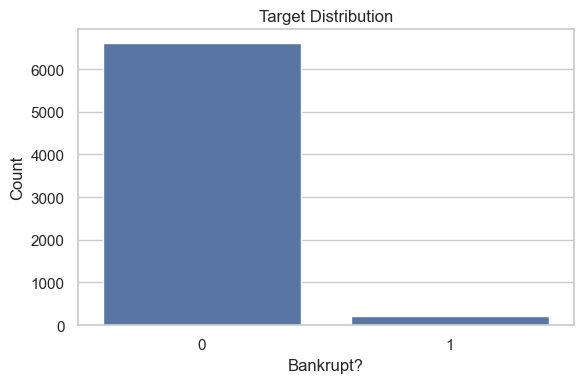

In [2]:
print("Shape:", df.shape)
print()
print("Missing values:", int(df.isna().sum().sum()))
print("Duplicate rows:", int(df.duplicated().sum()))

target_counts = df[TARGET].value_counts().sort_index()
target_percents = df[TARGET].value_counts(normalize=True).sort_index().mul(100)
target_summary = pd.DataFrame({"count": target_counts, "percent": target_percents.round(2)})
display(target_summary)

plt.figure(figsize=(6, 4))
sns.countplot(data=df, x=TARGET)
plt.title("Target Distribution")
plt.xlabel("Bankrupt?")
plt.ylabel("Count")
plt.tight_layout()
plt.show()


**Modeling observation**

Only about `3.2%` of rows belong to the positive class, so the dataset is highly imbalanced. That makes accuracy a weak primary metric and pushes the workflow toward `PR-AUC`, `Brier score`, and close attention to recall for the final operating point.



## 3. Train / Validation / Test Split

The split must be stratified and fixed across all five experiments.

- Train: `70%`
- Validation: `15%`
- Test: `15%`
- Random seed: `42`

The test set is created here but not used again until the final evaluation section.


In [3]:
X = df.drop(columns=[TARGET])
y = df[TARGET]

X_train, X_temp, y_train, y_temp = train_test_split(
    X,
    y,
    test_size=0.30,
    stratify=y,
    random_state=RANDOM_STATE,
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp,
    y_temp,
    test_size=0.50,
    stratify=y_temp,
    random_state=RANDOM_STATE,
)

print("Train shape:", X_train.shape)
print("Validation shape:", X_val.shape)
print("Test shape:", X_test.shape)
print()
print("Train class balance")
display(split_balance(y_train))
print("Validation class balance")
display(split_balance(y_val))
print("Test class balance")
display(split_balance(y_test))

Train shape: (4773, 95)
Validation shape: (1023, 95)
Test shape: (1023, 95)

Train class balance


,count,percent
Bankrupt?,,
0,4619,96.7700
1,154,3.2300


Validation class balance


,count,percent
Bankrupt?,,
0,990,96.7700
1,33,3.2300


Test class balance


,count,percent
Bankrupt?,,
0,990,96.7700
1,33,3.2300



## 4. Preprocessing

This dataset is mostly numeric, so the preprocessing stays intentionally simple.

- Separate `X` and `y`
- Remove the target from the feature matrix
- Confirm whether any categorical features exist
- Impute missing values if needed
- Scale only the logistic regression baseline
- Briefly scan for obvious leakage columns


In [4]:

numeric_columns = X_train.select_dtypes(include=[np.number]).columns.tolist()
categorical_columns = X_train.select_dtypes(exclude=[np.number]).columns.tolist()

print("Numeric columns:", len(numeric_columns))
print("Categorical columns:", len(categorical_columns))
if categorical_columns:
    print(categorical_columns)

logreg_preprocessor = ColumnTransformer(
    transformers=[
        (
            "num",
            Pipeline([
                ("imputer", SimpleImputer(strategy="median")),
                ("scaler", StandardScaler()),
            ]),
            numeric_columns,
        )
    ],
    remainder="drop",
)

xgb_preprocessor = ColumnTransformer(
    transformers=[("num", SimpleImputer(strategy="median"), numeric_columns)],
    remainder="drop",
)

suspected_leakage_columns = [
    column
    for column in X_train.columns
    if "bankrupt" in column.lower() or "target" in column.lower()
]
print("Possible leakage columns:", suspected_leakage_columns)


Numeric columns: 95
Categorical columns: 0
Possible leakage columns: []



## 5. Feature Sets

Two feature sets are compared.

- Feature Set A: all usable numeric features after basic cleaning
- Feature Set B: top `25` features from an XGBoost importance model fit on the training set only

Feature Set B is meant to test whether a smaller, easier-to-explain set can stay competitive without using the test set for selection.


In [5]:

feature_set_a = numeric_columns.copy()

feature_selector = Pipeline([
    ("preprocessor", xgb_preprocessor),
    (
        "model",
        XGBClassifier(
            random_state=RANDOM_STATE,
            eval_metric="logloss",
            n_estimators=200,
            learning_rate=0.05,
            max_depth=4,
        ),
    ),
])

feature_selector.fit(X_train[feature_set_a], y_train)
feature_set_b = select_top_features(
    feature_selector.named_steps["model"],
    feature_set_a,
    top_n=25,
)

print("Feature Set A size:", len(feature_set_a))
print("Feature Set B size:", len(feature_set_b))
print("Top 10 selected features:")
print(feature_set_b[:10])


Feature Set A size: 95
Feature Set B size: 25
Top 10 selected features:
[" Net Income to Stockholder's Equity", ' Persistent EPS in the Last Four Seasons', ' Debt ratio %', ' Net Value Growth Rate', ' Borrowing dependency', ' Total debt/Total net worth', ' Continuous interest rate (after tax)', ' Retained Earnings to Total Assets', ' Quick Ratio', ' ROA(B) before interest and depreciation after tax']



**Feature Set B notes**

- Selection method: XGBoost feature importance fit on the training split only
- Features kept: `25`
- Goal: test whether a smaller feature set can stay close in performance while being simpler to explain
- The test set is not involved in feature selection



## 6. Reusable Evaluation Function

The notebook uses reusable helpers from `src/model_utils.py` to keep the experiment workflow consistent across all five runs. Each experiment returns one row with the required validation metrics and the overfitting gap.



## 7. Five Experiments

Exactly five experiments are required.

1. Logistic Regression baseline on Feature Set A
2. XGBoost baseline on Feature Set A
3. XGBoost with class-imbalance handling on Feature Set A
4. XGBoost lightly tuned on Feature Set A
5. XGBoost on Feature Set B

All experiments use the same train and validation split. Threshold-based metrics are reported at `0.5` here so model comparison stays separate from the later threshold-selection step. Using the same default threshold for every experiment keeps the comparison fair before the finalist's threshold is tuned on the validation set.


In [6]:

results = []
experiment_models = {}
experiment_features = {}

logreg_model = Pipeline([
    ("preprocessor", logreg_preprocessor),
    ("model", LogisticRegression(max_iter=1000, random_state=RANDOM_STATE)),
])
experiment_models[1] = logreg_model
experiment_features[1] = feature_set_a
results.append(
    evaluate_experiment(
        exp_id=1,
        model_name="Logistic Regression",
        feature_set="A",
        estimator=logreg_model,
        X_train=X_train[feature_set_a],
        y_train=y_train,
        X_val=X_val[feature_set_a],
        y_val=y_val,
        main_settings="median impute + scale + default logistic regression",
        notes="Simple baseline",
    )
)

xgb_base = Pipeline([
    ("preprocessor", xgb_preprocessor),
    (
        "model",
        XGBClassifier(
            random_state=RANDOM_STATE,
            eval_metric="logloss",
            n_estimators=300,
            learning_rate=0.05,
            max_depth=4,
            reg_lambda=1.0,
        ),
    ),
])
experiment_models[2] = xgb_base
experiment_features[2] = feature_set_a
results.append(
    evaluate_experiment(
        exp_id=2,
        model_name="XGBoost Baseline",
        feature_set="A",
        estimator=xgb_base,
        X_train=X_train[feature_set_a],
        y_train=y_train,
        X_val=X_val[feature_set_a],
        y_val=y_val,
        main_settings="n_estimators=300, learning_rate=0.05, max_depth=4",
        notes="First serious model",
    )
)

scale_pos_weight = make_scale_pos_weight(y_train)
xgb_imbalance = Pipeline([
    ("preprocessor", xgb_preprocessor),
    (
        "model",
        XGBClassifier(
            random_state=RANDOM_STATE,
            eval_metric="logloss",
            n_estimators=300,
            learning_rate=0.05,
            max_depth=4,
            scale_pos_weight=scale_pos_weight,
            reg_lambda=1.0,
        ),
    ),
])
experiment_models[3] = xgb_imbalance
experiment_features[3] = feature_set_a
results.append(
    evaluate_experiment(
        exp_id=3,
        model_name="XGBoost Imbalance-Aware",
        feature_set="A",
        estimator=xgb_imbalance,
        X_train=X_train[feature_set_a],
        y_train=y_train,
        X_val=X_val[feature_set_a],
        y_val=y_val,
        main_settings=f"scale_pos_weight={scale_pos_weight:.2f}",
        notes="Improves recall with imbalance handling",
    )
)

xgb_tuned = Pipeline([
    ("preprocessor", xgb_preprocessor),
    (
        "model",
        XGBClassifier(
            random_state=RANDOM_STATE,
            eval_metric="logloss",
            n_estimators=500,
            learning_rate=0.03,
            max_depth=3,
            subsample=0.8,
            colsample_bytree=0.8,
            reg_lambda=2.0,
            gamma=0.0,
        ),
    ),
])
experiment_models[4] = xgb_tuned
experiment_features[4] = feature_set_a
results.append(
    evaluate_experiment(
        exp_id=4,
        model_name="XGBoost Tuned",
        feature_set="A",
        estimator=xgb_tuned,
        X_train=X_train[feature_set_a],
        y_train=y_train,
        X_val=X_val[feature_set_a],
        y_val=y_val,
        main_settings="n_estimators=500, learning_rate=0.03, max_depth=3, subsample=0.8, colsample_bytree=0.8, reg_lambda=2.0",
        notes="Light manual tuning over several key hyperparameters",
    )
)

xgb_selected = Pipeline([
    ("preprocessor", SimpleImputer(strategy="median")),
    (
        "model",
        XGBClassifier(
            random_state=RANDOM_STATE,
            eval_metric="logloss",
            n_estimators=300,
            learning_rate=0.05,
            max_depth=4,
            reg_lambda=1.0,
        ),
    ),
])
experiment_models[5] = xgb_selected
experiment_features[5] = feature_set_b
results.append(
    evaluate_experiment(
        exp_id=5,
        model_name="XGBoost Selected Features",
        feature_set="B",
        estimator=xgb_selected,
        X_train=X_train[feature_set_b],
        y_train=y_train,
        X_val=X_val[feature_set_b],
        y_val=y_val,
        main_settings="top 25 XGBoost importance features",
        notes="Checks whether a smaller feature set stays competitive",
    )
)

results_df = pd.DataFrame(results).sort_values("exp_id").reset_index(drop=True)
results_df["selected_finalist"] = "No"
results_df


,exp_id,model,feature_set,main_settings,train_pr_auc,val_pr_auc,overfit_gap,val_roc_auc,val_brier,threshold,val_precision,val_recall,val_f1_or_f2,selected_finalist,notes
0,1,Logistic Regression,A,median impute + scale + default logistic regre...,0.5308,0.2587,0.2721,0.8766,0.0316,0.5000,0.3333,0.1818,0.2000,No,Simple baseline
1,2,XGBoost Baseline,A,"n_estimators=300, learning_rate=0.05, max_depth=4",1.0000,0.5525,0.4475,0.9645,0.0207,0.5000,0.7692,0.3030,0.3448,No,First serious model
2,3,XGBoost Imbalance-Aware,A,scale_pos_weight=29.99,1.0000,0.5377,0.4623,0.9620,0.0242,0.5000,0.5263,0.6061,0.5882,No,Improves recall with imbalance handling
3,4,XGBoost Tuned,A,"n_estimators=500, learning_rate=0.03, max_dept...",0.9973,0.5831,0.4142,0.9665,0.0199,0.5000,0.6667,0.3030,0.3401,No,Light manual tuning over several key hyperpara...
4,5,XGBoost Selected Features,B,top 25 XGBoost importance features,0.9988,0.4430,0.5558,0.9522,0.0233,0.5000,0.6250,0.3030,0.3378,No,Checks whether a smaller feature set stays com...


In [7]:

results_df = results_df[
    [
        "exp_id",
        "model",
        "feature_set",
        "main_settings",
        "train_pr_auc",
        "val_pr_auc",
        "overfit_gap",
        "val_roc_auc",
        "val_brier",
        "threshold",
        "val_precision",
        "val_recall",
        "val_f1_or_f2",
        "selected_finalist",
        "notes",
    ]
]
results_df


,exp_id,model,feature_set,main_settings,train_pr_auc,val_pr_auc,overfit_gap,val_roc_auc,val_brier,threshold,val_precision,val_recall,val_f1_or_f2,selected_finalist,notes
0,1,Logistic Regression,A,median impute + scale + default logistic regre...,0.5308,0.2587,0.2721,0.8766,0.0316,0.5000,0.3333,0.1818,0.2000,No,Simple baseline
1,2,XGBoost Baseline,A,"n_estimators=300, learning_rate=0.05, max_depth=4",1.0000,0.5525,0.4475,0.9645,0.0207,0.5000,0.7692,0.3030,0.3448,No,First serious model
2,3,XGBoost Imbalance-Aware,A,scale_pos_weight=29.99,1.0000,0.5377,0.4623,0.9620,0.0242,0.5000,0.5263,0.6061,0.5882,No,Improves recall with imbalance handling
3,4,XGBoost Tuned,A,"n_estimators=500, learning_rate=0.03, max_dept...",0.9973,0.5831,0.4142,0.9665,0.0199,0.5000,0.6667,0.3030,0.3401,No,Light manual tuning over several key hyperpara...
4,5,XGBoost Selected Features,B,top 25 XGBoost importance features,0.9988,0.4430,0.5558,0.9522,0.0233,0.5000,0.6250,0.3030,0.3378,No,Checks whether a smaller feature set stays com...



## 8. Final Model Selection

The winner is chosen with the assignment rule:

1. Best validation `PR-AUC`
2. Better validation `Brier score` among models with similar `PR-AUC`
3. Reasonable overfit gap
4. Simpler model if performance is similar

The test set is still untouched at this point.


In [8]:

selection_columns = ["val_pr_auc", "val_brier", "overfit_gap"]
ranked_results = results_df.sort_values(selection_columns, ascending=[False, True, True]).reset_index(drop=True)
selected_exp_id = int(ranked_results.loc[0, "exp_id"])
results_df.loc[results_df["exp_id"] == selected_exp_id, "selected_finalist"] = "Yes"

print("Validation ranking used for final selection:")
display(ranked_results[["exp_id", "model", "val_pr_auc", "val_brier", "overfit_gap"]])

print("Selected finalist:")
display(results_df.loc[results_df["exp_id"] == selected_exp_id])


Validation ranking used for final selection:


,exp_id,model,val_pr_auc,val_brier,overfit_gap
0,4,XGBoost Tuned,0.5831,0.0199,0.4142
1,2,XGBoost Baseline,0.5525,0.0207,0.4475
2,3,XGBoost Imbalance-Aware,0.5377,0.0242,0.4623
3,5,XGBoost Selected Features,0.4430,0.0233,0.5558
4,1,Logistic Regression,0.2587,0.0316,0.2721


Selected finalist:


,exp_id,model,feature_set,main_settings,train_pr_auc,val_pr_auc,overfit_gap,val_roc_auc,val_brier,threshold,val_precision,val_recall,val_f1_or_f2,selected_finalist,notes
3,4,XGBoost Tuned,A,"n_estimators=500, learning_rate=0.03, max_dept...",0.9973,0.5831,0.4142,0.9665,0.0199,0.5000,0.6667,0.3030,0.3401,Yes,Light manual tuning over several key hyperpara...



## 9. Final Test Evaluation

Threshold selection happens only after the winning model is chosen.

- Use the selected model from the validation ranking
- Choose one threshold on the validation set only
- Apply that same threshold once to the untouched test set

The threshold strategy here is to maximize validation `F2-score`, which weights recall more heavily than precision and matches the assignment's business framing that false negatives are more costly.


Chosen validation threshold: 0.15
Validation F2 at chosen threshold: 0.6497


,metric,value
0,PR-AUC,0.5161
1,ROC-AUC,0.9549
2,Brier score,0.0225
3,Precision,0.3953
4,Recall,0.5152
5,F2-score,0.4857
6,F1-score,0.4474


Confusion matrix:
[[964  26]
 [ 16  17]]


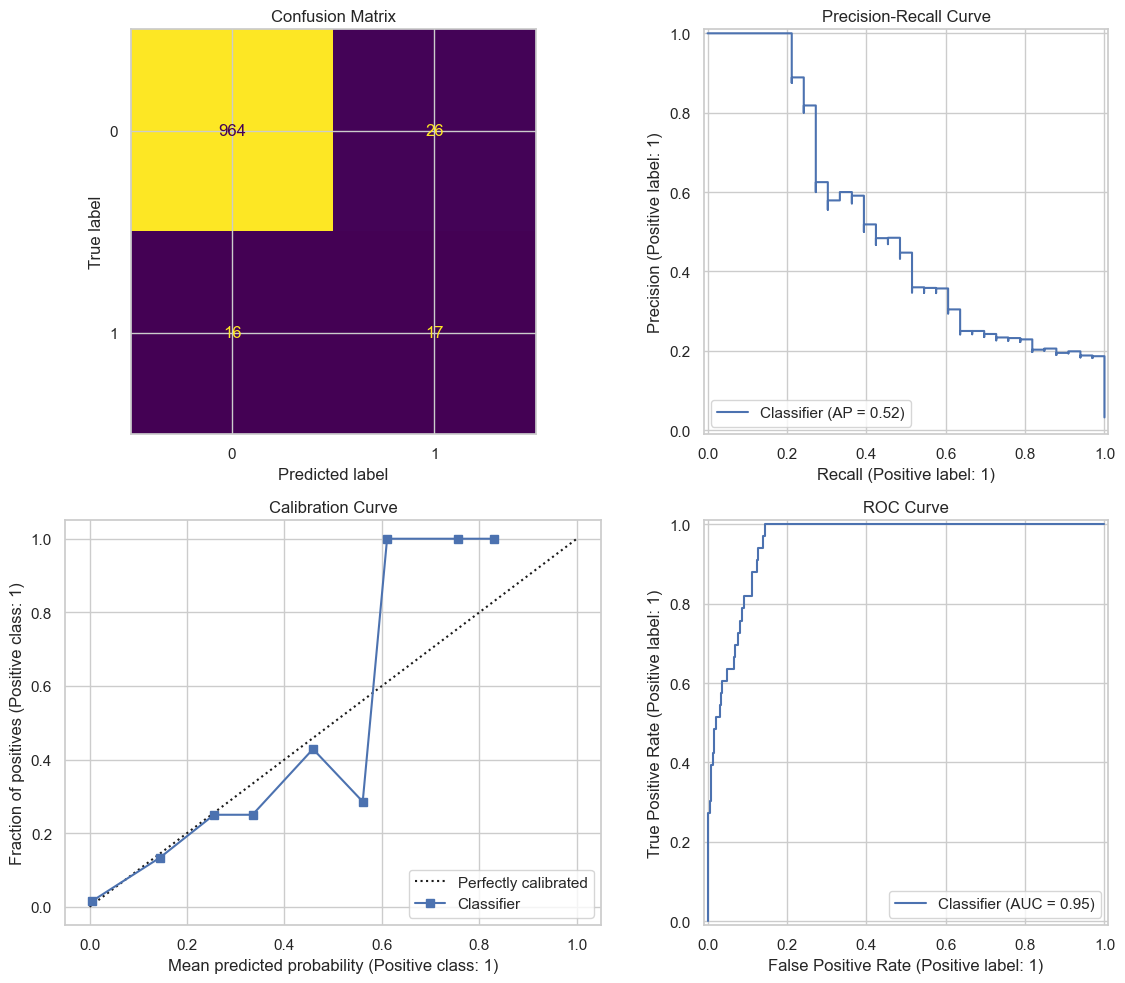

In [9]:

final_model = experiment_models[selected_exp_id]
final_features = experiment_features[selected_exp_id]

final_model.fit(X_train[final_features], y_train)
val_proba = final_model.predict_proba(X_val[final_features])[:, 1]
threshold_result = find_best_threshold(y_val, val_proba, optimize_metric="f2")
final_threshold = threshold_result.threshold

print("Chosen validation threshold:", final_threshold)
print("Validation F2 at chosen threshold:", round(threshold_result.score, 4))

test_proba = final_model.predict_proba(X_test[final_features])[:, 1]
test_pred = (test_proba >= final_threshold).astype(int)
test_metrics = compute_metrics(y_test, test_pred, test_proba)

test_results = pd.DataFrame(
    {
        "metric": ["PR-AUC", "ROC-AUC", "Brier score", "Precision", "Recall", "F2-score", "F1-score"],
        "value": [
            test_metrics["pr_auc"],
            test_metrics["roc_auc"],
            test_metrics["brier"],
            test_metrics["precision"],
            test_metrics["recall"],
            test_metrics["f2"],
            test_metrics["f1"],
        ],
    }
)
display(test_results)

cm = confusion_matrix(y_test, test_pred)
print("Confusion matrix:")
print(cm)

fig, axes = plt.subplots(2, 2, figsize=(12, 10))
ConfusionMatrixDisplay(cm).plot(ax=axes[0, 0], colorbar=False)
axes[0, 0].set_title("Confusion Matrix")

PrecisionRecallDisplay.from_predictions(y_test, test_proba, ax=axes[0, 1])
axes[0, 1].set_title("Precision-Recall Curve")

CalibrationDisplay.from_predictions(y_test, test_proba, n_bins=10, ax=axes[1, 0])
axes[1, 0].set_title("Calibration Curve")

RocCurveDisplay.from_predictions(y_test, test_proba, ax=axes[1, 1])
axes[1, 1].set_title("ROC Curve")

plt.tight_layout()
plt.show()


In [10]:

prob_true, prob_pred = calibration_curve(y_test, test_proba, n_bins=10, strategy="uniform")
calibration_df = pd.DataFrame(
    {
        "mean_predicted_probability": prob_pred,
        "observed_bankruptcy_rate": prob_true,
    }
)
calibration_df


,mean_predicted_probability,observed_bankruptcy_rate
0,0.0051,0.0154
1,0.1443,0.1333
2,0.2554,0.2500
3,0.3344,0.2500
4,0.4585,0.4286
5,0.5606,0.2857
6,0.6106,1.0000
7,0.7558,1.0000
8,0.8310,1.0000



## 10. Interpretability

A simple XGBoost feature-importance chart is enough for this assignment. It gives a fast sense of which features influenced the final model the most, even though it does not explain direction or causality as clearly as SHAP would.


,importance
Persistent EPS in the Last Four Seasons,0.0665
Net Value Growth Rate,0.0562
Borrowing dependency,0.0531
Net worth/Assets,0.0511
Continuous interest rate (after tax),0.0500
Net Income to Stockholder's Equity,0.0419
Quick Ratio,0.0207
Total debt/Total net worth,0.0193
Retained Earnings to Total Assets,0.0164
ROA(A) before interest and % after tax,0.0161


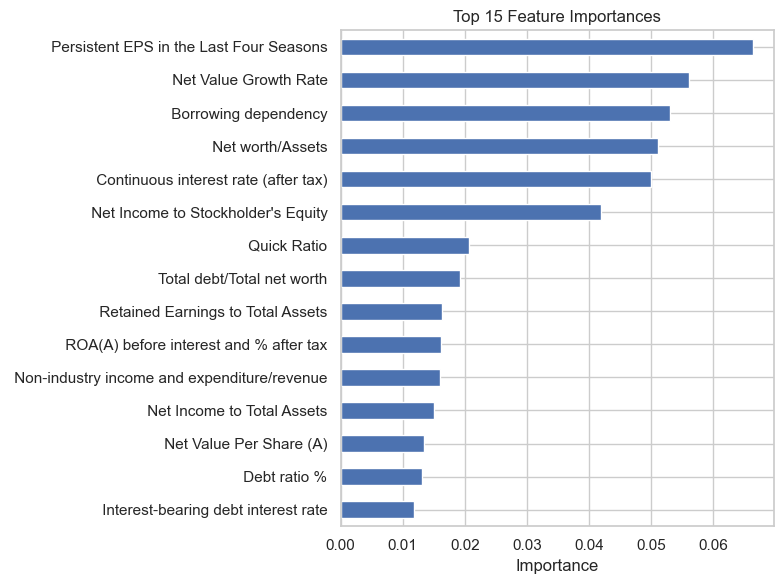

In [11]:

final_xgb = final_model.named_steps["model"]
importance = pd.Series(final_xgb.feature_importances_, index=final_features).sort_values(ascending=False)

display(importance.head(15).to_frame("importance"))

plt.figure(figsize=(8, 6))
importance.head(15).sort_values().plot(kind="barh")
plt.title("Top 15 Feature Importances")
plt.xlabel("Importance")
plt.tight_layout()
plt.show()



## 11. AI Usage

- AI tool used: Codex in VS Code
- What it helped with: organizing the notebook workflow, building the reusable evaluation helper, and cleaning up repetitive modeling code
- What I still had to verify myself: that the test set stayed untouched until the end and that the final model was chosen from validation `PR-AUC` and `Brier score`, not from the test set
- One weak suggestion I corrected: an earlier repo note said to select the final model mainly with `F2-score`, but that would not match the assignment rule, so the selection logic was changed to prioritize validation `PR-AUC`, `Brier score`, and overfitting evidence instead



## 12. Conclusion / Short Summary

- Logistic regression provided a useful baseline, but the XGBoost models separated risky firms much better.
- The lightly tuned XGBoost model became the finalist because it had the strongest validation `PR-AUC` and the best validation `Brier score` among the top contenders.
- The selected-features model was easier to explain, but it lost too much validation `PR-AUC` to be the final choice.
- The final model still shows a large train-versus-validation `PR-AUC` gap, so it is useful but clearly somewhat overfit.
- Threshold tuning on the validation set improved recall for the final operating point without using the test set to make that decision.
